# 이상치 파악 및 처리

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

In [5]:
# 데이터 로드
df = pd.read_csv('pandas/data/california_housing_test.csv')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.05,37.37,27.0,3885.0,661.0,1537.0,606.0,6.6085,344700.0
1,-118.30,34.26,43.0,1510.0,310.0,809.0,277.0,3.5990,176500.0
2,-117.81,33.78,27.0,3589.0,507.0,1484.0,495.0,5.7934,270500.0
3,-118.36,33.82,28.0,67.0,15.0,49.0,11.0,6.1359,330000.0
4,-119.67,36.33,19.0,1241.0,244.0,850.0,237.0,2.9375,81700.0


## Z-Score란?
> **"이 값이 평균에서 표준편차 몇 개만큼 떨어져 있는가?"** 를 나타내는 수치입니다.
>
> **공식: Z = (값 - 평균) / 표준편차**
>
> - Z = 0 → 딱 평균
> - Z = +2.0 → 평균보다 표준편차 2개 위 (매우 큰 값)
> - Z = -2.0 → 평균보다 표준편차 2개 아래 (매우 작은 값)

### 정규분포에서의 Z-Score 위치
```
                         평균(0)
                           ↓
         ┌────────────────╥────────────────┐
         │       ╱╲       ║       ╱╲       │
         │     ╱    ╲     ║     ╱    ╲     │
         │   ╱        ╲   ║   ╱        ╲   │
         │ ╱            ╲ ║ ╱            ╲ │
    ─────╱────────────────╨────────────────╲─────
   -3   -2   -1    0    +1   +2   +3
```

### 신뢰구간별 Z-Score 범위
| 신뢰구간 | Z-Score 범위 | 의미 | 범위 밖 = 이상치 비율 |
|---|---|---|---|
| **95%** | -1.96 ~ +1.96 | 100개 중 **95개**가 이 안에 | 약 5% |
| **98%** | -2.33 ~ +2.33 | 100개 중 **98개**가 이 안에 | 약 2% |
| **99%** | -2.58 ~ +2.58 | 100개 중 **99개**가 이 안에 | 약 1% |

> 실무에서는 **95% (±1.96)**를 가장 많이 사용합니다.

In [6]:
# === Z-Score 계산 예시 (키 데이터로 이해하기) ===
# 예시: 학생 10명의 키
heights = pd.Series([155, 160, 165, 168, 170, 172, 175, 178, 185, 210])

mean = heights.mean()    # 평균
std = heights.std()      # 표준편차

print(f"평균: {mean:.1f}cm, 표준편차: {std:.1f}cm")
print()

# Z-Score 직접 계산: (값 - 평균) / 표준편차
z_scores = (heights - mean) / std
print("=== 각 학생의 Z-Score ===")
for h, z in zip(heights, z_scores):
    status = "⚠ 이상치" if abs(z) > 1.96 else "  정상"
    print(f"  키 {h}cm → Z-Score: {z:+.2f}  {status}")

print()
print("※ |Z| > 1.96 (95% 신뢰구간 밖) → 이상치로 판단")

평균: 173.8cm, 표준편차: 15.4cm

=== 각 학생의 Z-Score ===
  키 155cm → Z-Score: -1.22    정상
  키 160cm → Z-Score: -0.90    정상
  키 165cm → Z-Score: -0.57    정상
  키 168cm → Z-Score: -0.38    정상
  키 170cm → Z-Score: -0.25    정상
  키 172cm → Z-Score: -0.12    정상
  키 175cm → Z-Score: +0.08    정상
  키 178cm → Z-Score: +0.27    정상
  키 185cm → Z-Score: +0.73    정상
  키 210cm → Z-Score: +2.35  ⚠ 이상치

※ |Z| > 1.96 (95% 신뢰구간 밖) → 이상치로 판단


## Z-Score로 이상치 탐지 (california_housing 데이터)
> `scipy.stats.zscore()`를 사용하면 한 줄로 Z-Score를 계산할 수 있습니다.

In [7]:
# === Z-Score로 median_house_value 이상치 탐지 ===
from scipy import stats

# Z-Score 계산 (scipy 사용 → 한 줄로 가능)
df['z_score'] = stats.zscore(df['median_house_value'])

print("=== Z-Score 기본 통계 ===")
print(df['z_score'].describe().round(2))
print()

# 95% 신뢰구간: Z-Score가 -1.96 ~ +1.96 사이인 데이터
normal_95 = df[(df['z_score'] >= -1.96) & (df['z_score'] <= 1.96)]
outlier_95 = df[(df['z_score'] < -1.96) | (df['z_score'] > 1.96)]

print("=== 95% 신뢰구간 (Z: ±1.96) ===")
print(f"  정상 데이터: {len(normal_95)}개 ({len(normal_95)/len(df)*100:.1f}%)")
print(f"  이상치 데이터: {len(outlier_95)}개 ({len(outlier_95)/len(df)*100:.1f}%)")
print()

# 99% 신뢰구간: Z-Score가 -2.58 ~ +2.58 사이인 데이터
normal_99 = df[(df['z_score'] >= -2.58) & (df['z_score'] <= 2.58)]
outlier_99 = df[(df['z_score'] < -2.58) | (df['z_score'] > 2.58)]

print("=== 99% 신뢰구간 (Z: ±2.58) ===")
print(f"  정상 데이터: {len(normal_99)}개 ({len(normal_99)/len(df)*100:.1f}%)")
print(f"  이상치 데이터: {len(outlier_99)}개 ({len(outlier_99)/len(df)*100:.1f}%)")
print()

# 이상치 데이터 샘플 확인
print("=== 95% 기준 이상치 샘플 (Z-Score가 큰 순) ===")
print(outlier_95[['median_house_value', 'z_score', 'median_income', 'longitude', 'latitude']]
      .sort_values('z_score', ascending=False).head(10).round(2))

=== Z-Score 기본 통계 ===
count    3000.00
mean        0.00
std         1.00
min        -1.62
25%        -0.75
50%        -0.25
75%         0.51
max         2.60
Name: z_score, dtype: float64

=== 95% 신뢰구간 (Z: ±1.96) ===
  정상 데이터: 2796개 (93.2%)
  이상치 데이터: 204개 (6.8%)

=== 99% 신뢰구간 (Z: ±2.58) ===
  정상 데이터: 2871개 (95.7%)
  이상치 데이터: 129개 (4.3%)

=== 95% 기준 이상치 샘플 (Z-Score가 큰 순) ===
      median_house_value  z_score  median_income  longitude  latitude
1625            500001.0      2.6           7.84    -118.55     34.17
1980            500001.0      2.6           5.25    -118.41     33.88
1872            500001.0      2.6           3.10    -118.38     34.05
1880            500001.0      2.6          10.38    -121.89     37.46
1886            500001.0      2.6           3.98    -117.35     33.16
1887            500001.0      2.6           4.75    -122.43     37.76
1904            500001.0      2.6           3.09    -122.45     37.77
1951            500001.0      2.6           4.58    -118.39   

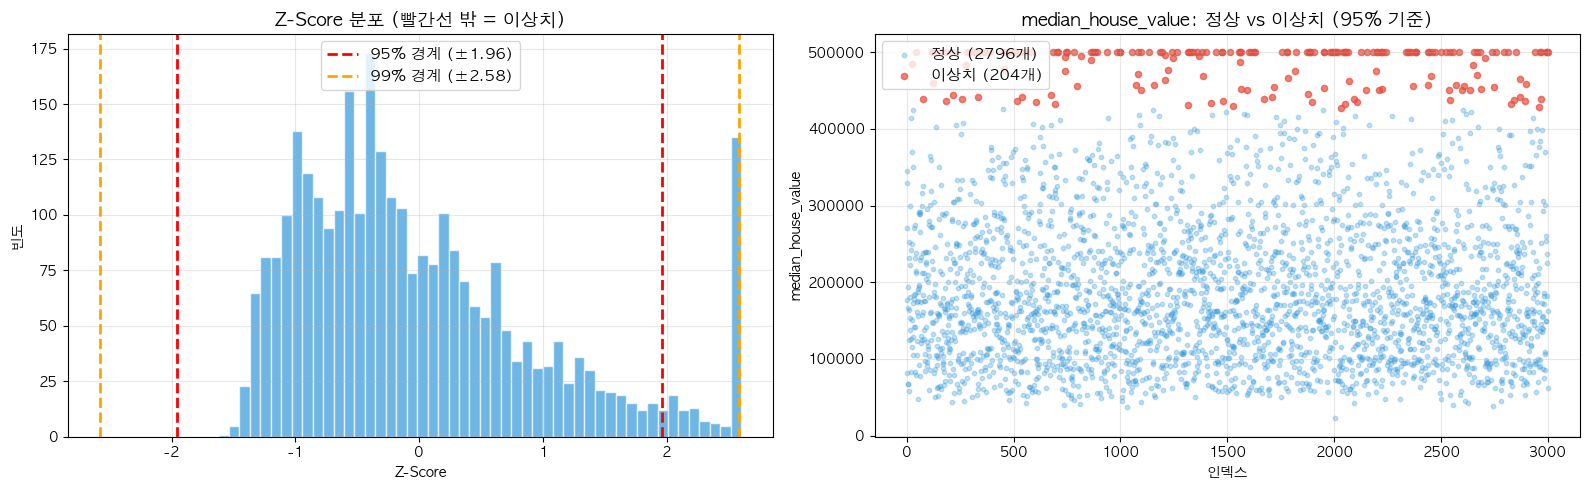

In [8]:
# === Z-Score 이상치 시각화 ===
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 그래프 1: Z-Score 분포 히스토그램 + 신뢰구간 경계선
axes[0].hist(df['z_score'], bins=50, color='#3498db', alpha=0.7, edgecolor='white')
# 95% 경계선 (±1.96)
axes[0].axvline(x=-1.96, color='red', linestyle='--', linewidth=2, label='95% 경계 (±1.96)')
axes[0].axvline(x=1.96, color='red', linestyle='--', linewidth=2)
# 99% 경계선 (±2.58)
axes[0].axvline(x=-2.58, color='orange', linestyle='--', linewidth=2, label='99% 경계 (±2.58)')
axes[0].axvline(x=2.58, color='orange', linestyle='--', linewidth=2)
axes[0].set_title('Z-Score 분포 (빨간선 밖 = 이상치)', fontsize=13)
axes[0].set_xlabel('Z-Score')
axes[0].set_ylabel('빈도')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# 그래프 2: 원본 값에서 이상치 표시
normal_mask = (df['z_score'] >= -1.96) & (df['z_score'] <= 1.96)
axes[1].scatter(df.index[normal_mask], df.loc[normal_mask, 'median_house_value'],
               c='#3498db', alpha=0.3, s=10, label=f'정상 ({normal_mask.sum()}개)')
axes[1].scatter(df.index[~normal_mask], df.loc[~normal_mask, 'median_house_value'],
               c='#e74c3c', alpha=0.7, s=20, label=f'이상치 ({(~normal_mask).sum()}개)')
axes[1].set_title('median_house_value: 정상 vs 이상치 (95% 기준)', fontsize=13)
axes[1].set_xlabel('인덱스')
axes[1].set_ylabel('median_house_value')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## IQR (사분위 범위)로 이상치 탐지

### IQR이란?
> **IQR = Q3 - Q1** (3사분위수 - 1사분위수)  
> 데이터의 **중간 50%가 퍼져있는 범위**를 의미합니다.

### 사분위수 이해하기
> 데이터를 **작은 순서로 정렬**한 뒤 **4등분**한 지점의 값입니다.

```
데이터를 작은 순서로 정렬:
[10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
  ↑                ↑                  ↑
  Q1(25%)         Q2(50%=중앙값)      Q3(75%)
  
  ← 하위 25% →← 중간 50% (IQR) →← 상위 25% →
```

| 용어 | 의미 | 위치 |
|---|---|---|
| **Q1** (1사분위수) | 하위 25% 지점 | 아래서 1/4 |
| **Q2** (2사분위수) | 중앙값 (50%) | 정중앙 |
| **Q3** (3사분위수) | 상위 25% 지점 | 아래서 3/4 |
| **IQR** | Q3 - Q1 | 중간 50%의 폭 |

### 이상치 판별 기준
```
                    IQR
            ┌───────┴───────┐
  ──────────┤               ├──────────
          Q1               Q3
          
  하한 경계 = Q1 - 1.5 × IQR    (이보다 작으면 이상치)
  상한 경계 = Q3 + 1.5 × IQR    (이보다 크면 이상치)
```

### 왜 1.5배인가?
> 정규분포에서 Q1 - 1.5×IQR ~ Q3 + 1.5×IQR 범위는 데이터의 약 **99.3%**를 포함합니다.  
> 즉, 이 범위 밖의 약 **0.7%** 데이터를 이상치로 판단하는 것입니다.
>
> | 배수 | 범위 밖 비율 | 용도 |
> |---|---|---|
> | **1.5 × IQR** | 약 0.7% | 일반 이상치 (가장 많이 사용) |
> | **3.0 × IQR** | 약 0.002% | 극단적 이상치 |

### 박스플롯과의 관계
> 박스플롯이 바로 **IQR을 시각화한 그래프**입니다!
```
              ◆ (극단 이상치)
              |
  ─────────── ┬ ── 상한 울타리 (Q3 + 1.5×IQR)
              |
         ┌────┤
         │    │ ← Q3 (75%)
         │    │
    박스  │────│ ← Q2 (중앙값, 50%)
         │    │
         │    │ ← Q1 (25%)
         └────┤
              |
  ─────────── ┴ ── 하한 울타리 (Q1 - 1.5×IQR)
              |
              ◆ (극단 이상치)
```

### Z-Score vs IQR 비교
| 비교 항목 | Z-Score | IQR |
|---|---|---|
| **기준** | 평균, 표준편차 | 사분위수 (Q1, Q3) |
| **전제 조건** | 정규분포에 가까울 때 정확 | **분포 상관없이** 사용 가능 |
| **이상치 영향** | 평균이 이상치에 끌려감 → 왜곡 가능 | 중앙값 기반이라 **이상치에 강함** |
| **실무 추천** | 데이터가 정규분포일 때 | **대부분의 경우 (더 안전)** |

In [10]:
# === IQR 계산 예시 (간단한 데이터로 이해하기) ===
# 예시: 학생 10명의 용돈 (단위: 만원)
pocket_money = pd.Series([5, 10, 15, 20, 25, 30, 35, 40, 45, 200])

print("=== 용돈 데이터 (정렬) ===")
print(pocket_money.sort_values().values)
print()

# 사분위수 계산
Q1 = pocket_money.quantile(0.25)   # 하위 25% 지점
Q2 = pocket_money.quantile(0.50)   # 중앙값 (50%)
Q3 = pocket_money.quantile(0.75)   # 상위 25% 지점
IQR = Q3 - Q1                      # 사분위 범위

print(f"Q1 (25%): {Q1}만원")
print(f"Q2 (50%, 중앙값): {Q2}만원")
print(f"Q3 (75%): {Q3}만원")
print(f"IQR (Q3-Q1): {IQR}만원")
print()

# 이상치 경계 계산
lower_bound = Q1 - 1.5 * IQR   # 하한 경계
upper_bound = Q3 + 1.5 * IQR   # 상한 경계
print(f"하한 경계: {Q1} - 1.5 × {IQR} = {lower_bound}만원")
print(f"상한 경계: {Q3} + 1.5 × {IQR} = {upper_bound}만원")
print()

# 이상치 판별
for val in pocket_money.sort_values():
    if val < lower_bound:
        status = "⚠ 하한 이상치 (너무 작음)"
    elif val > upper_bound:
        status = "⚠ 상한 이상치 (너무 큼)"
    else:
        status = "  정상"
    print(f"  용돈 {val:>3}만원 {status}")

print()
print("※ 200만원은 상한 경계를 넘으므로 이상치로 판단!")

=== 용돈 데이터 (정렬) ===
[  5  10  15  20  25  30  35  40  45 200]

Q1 (25%): 16.25만원
Q2 (50%, 중앙값): 27.5만원
Q3 (75%): 38.75만원
IQR (Q3-Q1): 22.5만원

하한 경계: 16.25 - 1.5 × 22.5 = -17.5만원
상한 경계: 38.75 + 1.5 × 22.5 = 72.5만원

  용돈   5만원   정상
  용돈  10만원   정상
  용돈  15만원   정상
  용돈  20만원   정상
  용돈  25만원   정상
  용돈  30만원   정상
  용돈  35만원   정상
  용돈  40만원   정상
  용돈  45만원   정상
  용돈 200만원 ⚠ 상한 이상치 (너무 큼)

※ 200만원은 상한 경계를 넘으므로 이상치로 판단!


### IQR로 이상치 탐지 (california_housing 데이터)
> `median_house_value`에 IQR 방식을 적용하여 이상치를 찾고, 박스플롯으로 확인합니다.

In [11]:
# === IQR로 median_house_value 이상치 탐지 ===
col = 'median_house_value'

# 사분위수 및 IQR 계산
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

# 이상치 경계
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("=== IQR 이상치 탐지 결과 ===")
print(f"Q1 (25%):     {Q1:>12,.0f}")
print(f"Q3 (75%):     {Q3:>12,.0f}")
print(f"IQR (Q3-Q1):  {IQR:>12,.0f}")
print(f"하한 경계:     {lower_bound:>12,.0f}")
print(f"상한 경계:     {upper_bound:>12,.0f}")
print()

# 이상치 분류
outlier_lower = df[df[col] < lower_bound]   # 하한 이상치
outlier_upper = df[df[col] > upper_bound]   # 상한 이상치
normal_iqr = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]  # 정상

print(f"하한 이상치: {len(outlier_lower)}개 (비정상적으로 싼 집)")
print(f"상한 이상치: {len(outlier_upper)}개 (비정상적으로 비싼 집)")
print(f"정상 데이터: {len(normal_iqr)}개")
print(f"이상치 비율: {(len(outlier_lower)+len(outlier_upper))/len(df)*100:.1f}%")
print()

# 이상치 샘플 확인
if len(outlier_upper) > 0:
    print("=== 상한 이상치 샘플 (비싼 순) ===")
    print(outlier_upper[[col, 'median_income', 'longitude', 'latitude']]
          .sort_values(col, ascending=False).head(10))

=== IQR 이상치 탐지 결과 ===
Q1 (25%):          121,200
Q3 (75%):          263,975
IQR (Q3-Q1):       142,775
하한 경계:          -92,962
상한 경계:          478,138

하한 이상치: 0개 (비정상적으로 싼 집)
상한 이상치: 141개 (비정상적으로 비싼 집)
정상 데이터: 2859개
이상치 비율: 4.7%

=== 상한 이상치 샘플 (비싼 순) ===
      median_house_value  median_income  longitude  latitude
2999            500001.0         8.5608    -119.63     34.42
1777            500001.0         6.1323    -122.39     37.59
2004            500001.0        11.1978    -118.47     34.10
1993            500001.0         5.6230    -119.64     34.43
1991            500001.0         3.6728    -122.41     37.81
1980            500001.0         5.2533    -118.41     33.88
1954            500001.0        11.5706    -122.47     37.87
1951            500001.0         4.5817    -118.39     33.82
1904            500001.0         3.0906    -122.45     37.77
1887            500001.0         4.7500    -122.43     37.76


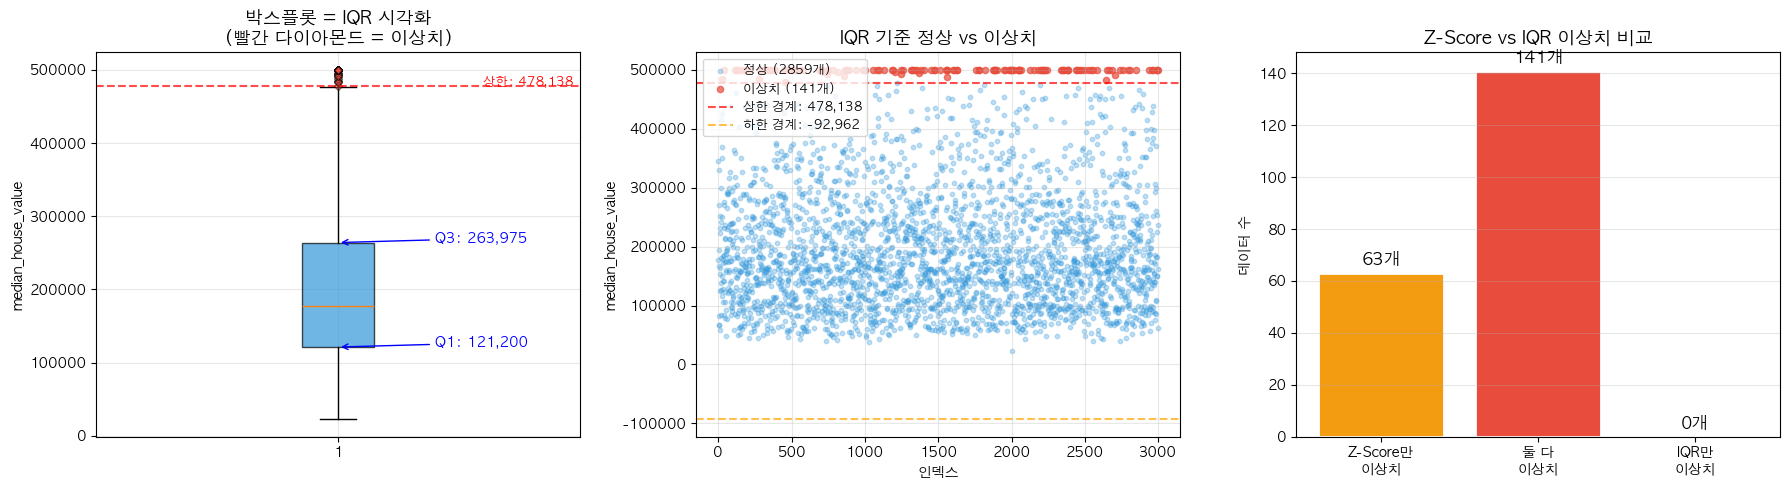


※ Z-Score 이상치: 204개 | IQR 이상치: 141개 | 둘 다 이상치: 141개
※ 두 방법의 결과가 다를 수 있으므로, 도메인 지식과 함께 종합적으로 판단하는 것이 중요합니다.


In [12]:
# === IQR 이상치 시각화: 박스플롯 + 산점도 ===
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 그래프 1: 박스플롯 (IQR 시각화 그 자체)
bp = axes[0].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                      boxprops=dict(facecolor='#3498db', alpha=0.7),
                      flierprops=dict(marker='D', markerfacecolor='#e74c3c', markersize=4, alpha=0.5))
axes[0].set_title('박스플롯 = IQR 시각화\n(빨간 다이아몬드 = 이상치)', fontsize=13)
axes[0].set_ylabel(col)
# Q1, Q3, 경계선 텍스트 표시
axes[0].annotate(f'Q3: {Q3:,.0f}', xy=(1.0, Q3), xytext=(1.2, Q3),
                fontsize=10, color='blue', arrowprops=dict(arrowstyle='->', color='blue'))
axes[0].annotate(f'Q1: {Q1:,.0f}', xy=(1.0, Q1), xytext=(1.2, Q1),
                fontsize=10, color='blue', arrowprops=dict(arrowstyle='->', color='blue'))
axes[0].axhline(y=upper_bound, color='red', linestyle='--', alpha=0.7)
axes[0].text(1.3, upper_bound, f'상한: {upper_bound:,.0f}', fontsize=9, color='red')
axes[0].grid(True, alpha=0.3)

# 그래프 2: 정상 vs 이상치 산점도
iqr_mask = (df[col] >= lower_bound) & (df[col] <= upper_bound)
axes[1].scatter(df.index[iqr_mask], df.loc[iqr_mask, col],
               c='#3498db', alpha=0.3, s=10, label=f'정상 ({iqr_mask.sum()}개)')
axes[1].scatter(df.index[~iqr_mask], df.loc[~iqr_mask, col],
               c='#e74c3c', alpha=0.7, s=20, label=f'이상치 ({(~iqr_mask).sum()}개)')
axes[1].axhline(y=upper_bound, color='red', linestyle='--', alpha=0.7, label=f'상한 경계: {upper_bound:,.0f}')
axes[1].axhline(y=lower_bound, color='orange', linestyle='--', alpha=0.7, label=f'하한 경계: {lower_bound:,.0f}')
axes[1].set_title('IQR 기준 정상 vs 이상치', fontsize=13)
axes[1].set_xlabel('인덱스')
axes[1].set_ylabel(col)
axes[1].legend(fontsize=9, loc='upper left')
axes[1].grid(True, alpha=0.3)

# 그래프 3: Z-Score vs IQR 이상치 비교
z_outlier = (df['z_score'] < -1.96) | (df['z_score'] > 1.96)
iqr_outlier = ~iqr_mask

# 벤다이어그램 대신 숫자로 비교
both = (z_outlier & iqr_outlier).sum()       # 둘 다 이상치
only_z = (z_outlier & ~iqr_outlier).sum()    # Z-Score만 이상치
only_iqr = (~z_outlier & iqr_outlier).sum()  # IQR만 이상치

labels = ['Z-Score만\n이상치', '둘 다\n이상치', 'IQR만\n이상치']
values = [only_z, both, only_iqr]
colors = ['#f39c12', '#e74c3c', '#9b59b6']
bars = axes[2].bar(labels, values, color=colors, edgecolor='white', linewidth=2)
for bar, val in zip(bars, values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                f'{val}개', ha='center', fontsize=12, fontweight='bold')
axes[2].set_title('Z-Score vs IQR 이상치 비교', fontsize=13)
axes[2].set_ylabel('데이터 수')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\n※ Z-Score 이상치: {z_outlier.sum()}개 | IQR 이상치: {iqr_outlier.sum()}개 | 둘 다 이상치: {both}개")
print("※ 두 방법의 결과가 다를 수 있으므로, 도메인 지식과 함께 종합적으로 판단하는 것이 중요합니다.")

---
# 이상치 처리 방법

> 이상치를 **발견**했으면, 이제 **어떻게 처리할지** 결정해야 합니다.  
> 크게 4가지 방법이 있습니다.

```
이상치 발견! → 어떻게 할까?

  ① 삭제        → 이상치 행을 아예 제거
  ② 경계값 대체  → 상한/하한 경계값으로 바꿈 (Capping/Winsorizing)
  ③ 변환        → 로그 변환 등으로 분포를 압축
  ④ 별도 처리    → 이상치를 따로 분리하여 별도 분석
```

| 방법 | 장점 | 단점 | 적합한 상황 |
|---|---|---|---|
| **① 삭제** | 간단, 깔끔 | 데이터 손실 | 이상치가 적고, 오류 데이터일 때 |
| **② 경계값 대체** | 데이터 손실 없음 | 원래 값 왜곡 | 이상치가 많아 삭제하면 손실이 클 때 |
| **③ 로그 변환** | 분포 자체를 개선 | 0/음수 불가 | 오른쪽으로 치우친 분포 (소득, 가격) |
| **④ 별도 분리** | 정보 보존 | 복잡 | 이상치 자체가 의미 있을 때 |

## 방법 ① 이상치 삭제
> 이상치가 포함된 **행 자체를 제거**합니다.  
> 가장 간단하지만 데이터가 줄어드는 단점이 있습니다.
>
> **쉬운 비유**: 반 평균을 구할 때, 시험을 안 본 학생(0점)을 아예 빼고 계산하는 것

In [13]:
# === 방법 ① 이상치 삭제 ===
col = 'median_house_value'

# IQR 경계 계산
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"삭제 전 데이터 수: {len(df)}개")
print(f"이상치 경계: {lower_bound:,.0f} ~ {upper_bound:,.0f}")
print()

# 이상치가 아닌 데이터만 남기기 (= 경계 안에 있는 데이터만 선택)
df_removed = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)].copy()

print(f"삭제 후 데이터 수: {len(df_removed)}개")
print(f"삭제된 이상치: {len(df) - len(df_removed)}개 ({(len(df)-len(df_removed))/len(df)*100:.1f}%)")
print()
print(f"삭제 전 평균: {df[col].mean():>12,.0f}")
print(f"삭제 후 평균: {df_removed[col].mean():>12,.0f}")
print(f"삭제 전 표준편차: {df[col].std():>8,.0f}")
print(f"삭제 후 표준편차: {df_removed[col].std():>8,.0f}  ← 편차가 줄어듦")

삭제 전 데이터 수: 3000개
이상치 경계: -92,962 ~ 478,138

삭제 후 데이터 수: 2859개
삭제된 이상치: 141개 (4.7%)

삭제 전 평균:      205,846
삭제 후 평균:      191,384
삭제 전 표준편차:  113,120
삭제 후 표준편차:   94,738  ← 편차가 줄어듦


## 방법 ② 경계값 대체 (Capping / Winsorizing)
> 이상치를 삭제하지 않고, **상한/하한 경계값으로 바꿔치기** 합니다.  
> 데이터 개수를 유지하면서 극단값의 영향을 줄일 수 있습니다.
>
> **쉬운 비유**: 시험 점수가 120점(만점 초과)이면 100점으로 바꿔주는 것
>
> ```
> 원본:    [10, 20, 30, ..., 500000, 600000]
>                                ↓ 상한(478,000)으로 대체
> 대체 후: [10, 20, 30, ..., 478000, 478000]
> ```

In [14]:
# === 방법 ② 경계값 대체 (Capping) ===
df_capped = df.copy()

print(f"대체 전 최솟값: {df_capped[col].min():>12,.0f}")
print(f"대체 전 최댓값: {df_capped[col].max():>12,.0f}")
print()

# clip(): 지정한 범위 밖의 값을 경계값으로 대체
# lower_bound 미만 → lower_bound로, upper_bound 초과 → upper_bound로
df_capped[col] = df_capped[col].clip(lower=lower_bound, upper=upper_bound)

print(f"대체 후 최솟값: {df_capped[col].min():>12,.0f}")
print(f"대체 후 최댓값: {df_capped[col].max():>12,.0f}")
print()
print(f"데이터 수 변화: {len(df)}개 → {len(df_capped)}개 (변동 없음!)")
print()
print(f"대체 전 평균: {df[col].mean():>12,.0f}")
print(f"대체 후 평균: {df_capped[col].mean():>12,.0f}")
print(f"대체 전 표준편차: {df[col].std():>8,.0f}")
print(f"대체 후 표준편차: {df_capped[col].std():>8,.0f}  ← 편차가 줄어듦")
print()
print("※ clip() 한 줄로 상한/하한 모두 처리 가능!")

대체 전 최솟값:       22,500
대체 전 최댓값:      500,001

대체 후 최솟값:       22,500
대체 후 최댓값:      478,138

데이터 수 변화: 3000개 → 3000개 (변동 없음!)

대체 전 평균:      205,846
대체 후 평균:      204,862
대체 전 표준편차:  113,120
대체 후 표준편차:  110,624  ← 편차가 줄어듦

※ clip() 한 줄로 상한/하한 모두 처리 가능!


## 방법 ③ 로그 변환 (Log Transformation)
> 데이터에 **로그(log)를 씌워서** 큰 값을 압축하고 분포를 고르게 만듭니다.  
> 이상치를 삭제하거나 바꾸지 않고, **분포 자체를 변환**하는 방법입니다.
>
> **쉬운 비유**: 부자와 가난한 사람의 소득 격차가 너무 크면, "소득"이 아니라 "소득의 자릿수"로 비교하는 것
>
> ```
> 원본:    10,000  100,000  1,000,000   ← 격차 990,000
> log 변환: 4.0     5.0      6.0        ← 격차 2.0 (압축됨!)
> ```
>
> **주의**: log(0)은 계산 불가 → `np.log1p()` (= log(1+x)) 사용

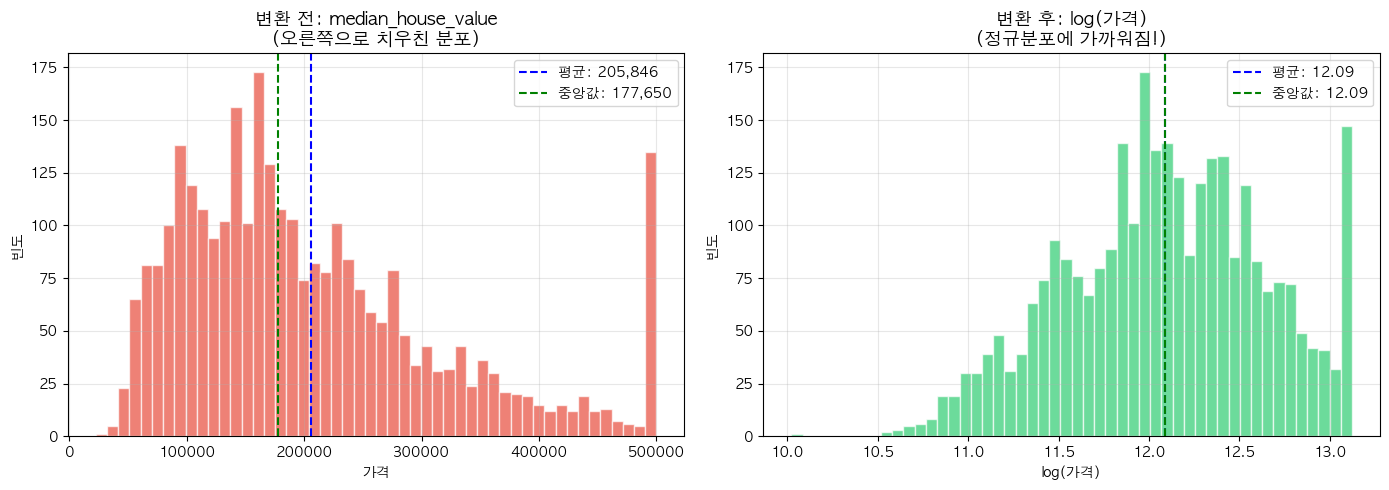

※ 변환 전: 평균과 중앙값의 차이가 큼 → 오른쪽으로 치우침
※ 변환 후: 평균과 중앙값이 비슷 → 정규분포에 가까움

※ 원래 값으로 되돌리기: np.expm1() (= e^x - 1)
   예: log1p(344700) = 12.7504
   복원: expm1(12.7504) = 344,700


In [15]:
# === 방법 ③ 로그 변환 ===
df_log = df.copy()

# np.log1p(): log(1 + x)를 계산 (x=0일 때도 안전)
df_log[col + '_log'] = np.log1p(df_log[col])

# 변환 전후 비교
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 그래프 1: 변환 전 분포
axes[0].hist(df[col], bins=50, color='#e74c3c', alpha=0.7, edgecolor='white')
axes[0].set_title(f'변환 전: {col}\n(오른쪽으로 치우친 분포)', fontsize=13)
axes[0].set_xlabel('가격')
axes[0].set_ylabel('빈도')
axes[0].axvline(x=df[col].mean(), color='blue', linestyle='--', label=f'평균: {df[col].mean():,.0f}')
axes[0].axvline(x=df[col].median(), color='green', linestyle='--', label=f'중앙값: {df[col].median():,.0f}')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# 그래프 2: 로그 변환 후 분포
axes[1].hist(df_log[col + '_log'], bins=50, color='#2ecc71', alpha=0.7, edgecolor='white')
axes[1].set_title('변환 후: log(가격)\n(정규분포에 가까워짐!)', fontsize=13)
axes[1].set_xlabel('log(가격)')
axes[1].set_ylabel('빈도')
log_mean = df_log[col + '_log'].mean()
log_median = df_log[col + '_log'].median()
axes[1].axvline(x=log_mean, color='blue', linestyle='--', label=f'평균: {log_mean:.2f}')
axes[1].axvline(x=log_median, color='green', linestyle='--', label=f'중앙값: {log_median:.2f}')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("※ 변환 전: 평균과 중앙값의 차이가 큼 → 오른쪽으로 치우침")
print("※ 변환 후: 평균과 중앙값이 비슷 → 정규분포에 가까움")
print()
print("※ 원래 값으로 되돌리기: np.expm1() (= e^x - 1)")
print(f"   예: log1p(344700) = {np.log1p(344700):.4f}")
print(f"   복원: expm1({np.log1p(344700):.4f}) = {np.expm1(np.log1p(344700)):,.0f}")

## 방법 ④ 별도 분리 (이상치를 따로 분석)
> 이상치가 **오류가 아니라 의미 있는 데이터**일 수 있습니다.  
> 예: 집값이 50만 달러 이상인 집 → "고급 주택"으로 분리하여 따로 분석
>
> **쉬운 비유**: 마라톤 기록에서 "프로 선수"와 "일반인"을 섞어서 평균내면 의미가 없으니 따로 분석하는 것

In [16]:
# === 방법 ④ 이상치 별도 분리 ===
# 정상 그룹과 이상치 그룹으로 분리
df_normal = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)].copy()
df_outlier = df[(df[col] < lower_bound) | (df[col] > upper_bound)].copy()

print(f"정상 그룹: {len(df_normal)}개")
print(f"이상치 그룹: {len(df_outlier)}개")
print()

# 두 그룹의 특성 비교
print("=== 정상 그룹 vs 이상치 그룹 주요 통계 비교 ===")
compare_cols = ['median_house_value', 'median_income', 'housing_median_age', 'total_rooms']
comparison = pd.DataFrame({
    '정상 그룹 평균': df_normal[compare_cols].mean(),
    '이상치 그룹 평균': df_outlier[compare_cols].mean(),
    '차이 배수': (df_outlier[compare_cols].mean() / df_normal[compare_cols].mean()).round(2)
})
print(comparison.round(0))
print()
print("※ 이상치 그룹은 소득이 높고, 집이 크고, 가격이 비싼 '고급 주택' 특성을 보임")
print("※ 이런 경우 삭제보다는 별도로 분리해서 '일반 주택'과 '고급 주택'을 나눠 분석하는 게 좋음")

정상 그룹: 2859개
이상치 그룹: 141개

=== 정상 그룹 vs 이상치 그룹 주요 통계 비교 ===
                    정상 그룹 평균  이상치 그룹 평균  차이 배수
median_house_value  191384.0   499085.0    3.0
median_income            4.0        7.0    2.0
housing_median_age      29.0       34.0    1.0
total_rooms           2574.0     3116.0    1.0

※ 이상치 그룹은 소득이 높고, 집이 크고, 가격이 비싼 '고급 주택' 특성을 보임
※ 이런 경우 삭제보다는 별도로 분리해서 '일반 주택'과 '고급 주택'을 나눠 분석하는 게 좋음


## 4가지 방법 비교 시각화
> 각 처리 방법을 적용한 후의 **분포 변화**를 한눈에 비교합니다.

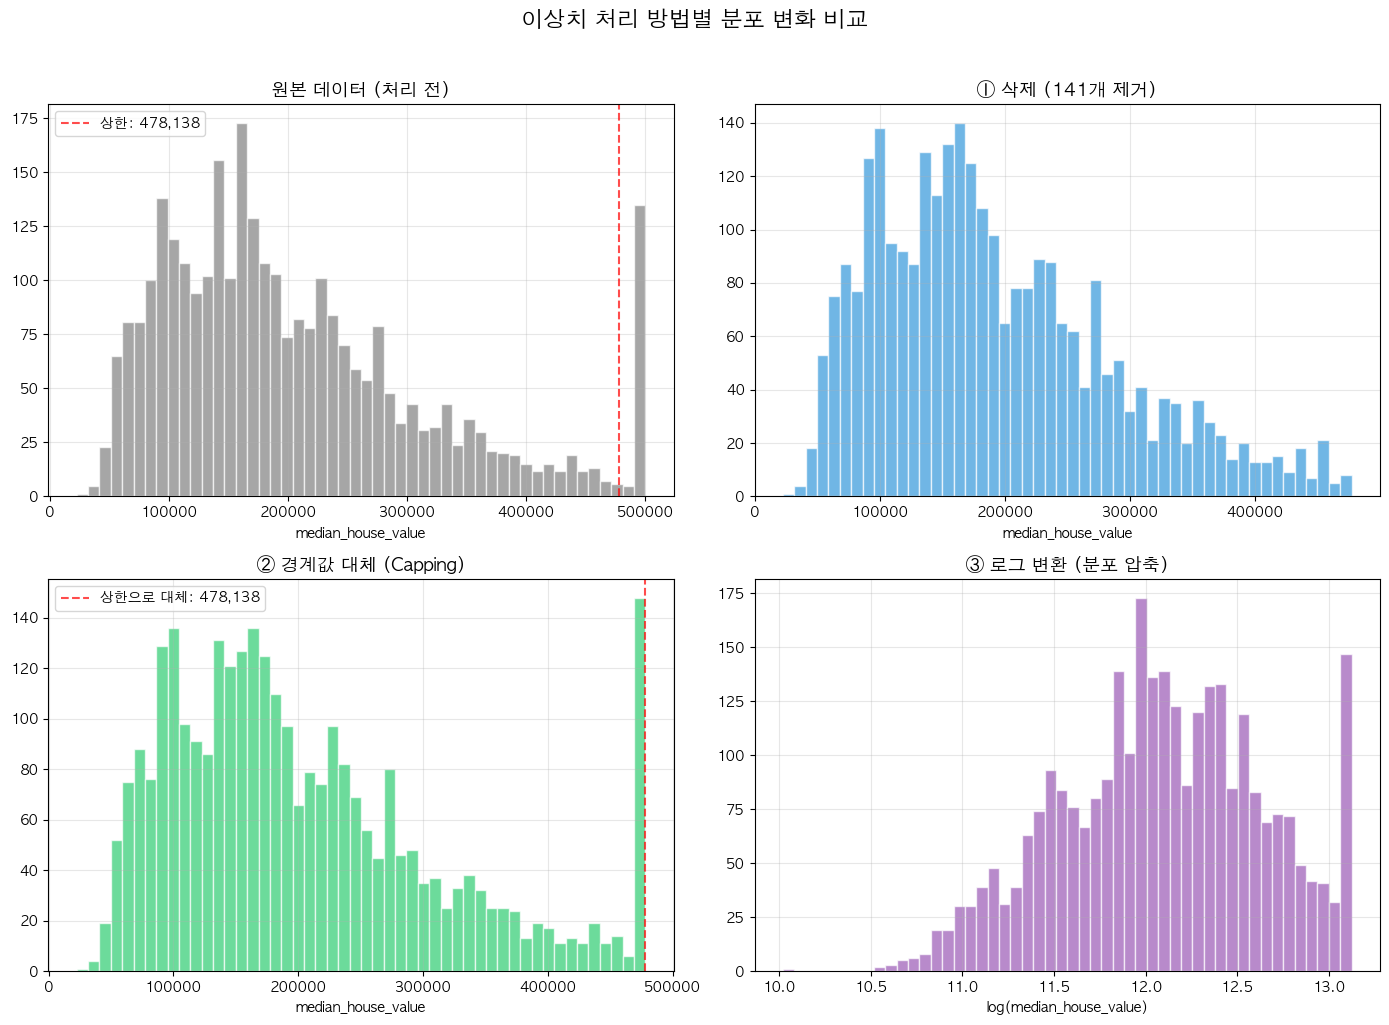

=== 처리 방법별 통계 요약 ===
             원본      ① 삭제  ② Capping  ③ 로그변환
count    3000.0    2859.0     3000.0  3000.0
mean   205846.0  191384.0   204862.0    12.0
std    113120.0   94738.0   110624.0     1.0
min     22500.0   22500.0    22500.0    10.0
25%    121200.0  117000.0   121200.0    12.0
50%    177650.0  172700.0   177650.0    12.0
75%    263975.0  247550.0   263975.0    12.0
max    500001.0  477100.0   478138.0    13.0

※ 어떤 방법이 '정답'은 없습니다.
※ 데이터의 특성과 분석 목적에 맞게 선택해야 합니다.
  - 이상치가 오류(입력 실수 등) → ① 삭제
  - 이상치가 많아 삭제 부담 → ② Capping
  - 분포가 심하게 치우침 → ③ 로그 변환
  - 이상치에 의미가 있음 → ④ 별도 분리 분석


In [17]:
# === 4가지 방법 처리 후 분포 비교 ===
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 원본 분포
axes[0][0].hist(df[col], bins=50, color='gray', alpha=0.7, edgecolor='white')
axes[0][0].set_title('원본 데이터 (처리 전)', fontsize=13)
axes[0][0].axvline(x=upper_bound, color='red', linestyle='--', alpha=0.7, label=f'상한: {upper_bound:,.0f}')
axes[0][0].legend(fontsize=10)
axes[0][0].set_xlabel(col)
axes[0][0].grid(True, alpha=0.3)

# ① 삭제 후
axes[0][1].hist(df_removed[col], bins=50, color='#3498db', alpha=0.7, edgecolor='white')
axes[0][1].set_title(f'① 삭제 ({len(df)-len(df_removed)}개 제거)', fontsize=13)
axes[0][1].set_xlabel(col)
axes[0][1].grid(True, alpha=0.3)

# ② 경계값 대체 후
axes[1][0].hist(df_capped[col], bins=50, color='#2ecc71', alpha=0.7, edgecolor='white')
axes[1][0].set_title('② 경계값 대체 (Capping)', fontsize=13)
axes[1][0].axvline(x=upper_bound, color='red', linestyle='--', alpha=0.7, label=f'상한으로 대체: {upper_bound:,.0f}')
axes[1][0].legend(fontsize=10)
axes[1][0].set_xlabel(col)
axes[1][0].grid(True, alpha=0.3)

# ③ 로그 변환 후
axes[1][1].hist(df_log[col + '_log'], bins=50, color='#9b59b6', alpha=0.7, edgecolor='white')
axes[1][1].set_title('③ 로그 변환 (분포 압축)', fontsize=13)
axes[1][1].set_xlabel(f'log({col})')
axes[1][1].grid(True, alpha=0.3)

plt.suptitle('이상치 처리 방법별 분포 변화 비교', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# 통계 요약 비교
print("=== 처리 방법별 통계 요약 ===")
summary = pd.DataFrame({
    '원본': df[col].describe(),
    '① 삭제': df_removed[col].describe(),
    '② Capping': df_capped[col].describe(),
    '③ 로그변환': df_log[col + '_log'].describe(),
}).round(0)
print(summary)
print()
print("※ 어떤 방법이 '정답'은 없습니다.")
print("※ 데이터의 특성과 분석 목적에 맞게 선택해야 합니다.")
print("  - 이상치가 오류(입력 실수 등) → ① 삭제")
print("  - 이상치가 많아 삭제 부담 → ② Capping")
print("  - 분포가 심하게 치우침 → ③ 로그 변환")
print("  - 이상치에 의미가 있음 → ④ 별도 분리 분석")

---
## 이상치 처리 방법별 장단점 정리

### ① 삭제 (Drop)
| | 내용 |
|---|---|
| **장점** | 가장 간단, 깔끔한 데이터 확보, 모델 학습 시 왜곡 방지 |
| **단점** | 데이터 손실 (이상치가 많으면 큰 손실), 이상치가 정보를 담고 있으면 그 정보도 사라짐 |
| **적합** | 이상치가 **입력 오류/측정 실수**이고, 전체의 1~2% 이하일 때 |
| **위험** | 이상치가 5% 이상이면 데이터 편향 발생 가능 |

### ② 경계값 대체 (Capping / Winsorizing)
| | 내용 |
|---|---|
| **장점** | 데이터 수 유지, `clip()` 한 줄로 간단, 극단값 영향만 줄임 |
| **단점** | 경계값에 데이터가 몰림 (인위적 분포), 원래 값의 차이 정보 손실 |
| **적합** | 이상치가 **많아서 삭제하면 손실이 클 때**, 분포 형태를 크게 바꾸고 싶지 않을 때 |
| **위험** | 50만 달러 집과 100만 달러 집이 같은 값(경계값)으로 뭉뚱그려짐 |

### ③ 로그 변환 (Log Transformation)
| | 내용 |
|---|---|
| **장점** | 삭제/대체 없이 분포 자체를 개선, 이상치 영향 자연스럽게 감소, 정규분포에 가까워져 모델 성능 향상 |
| **단점** | **0이나 음수** 값이 있으면 사용 불가 (log1p로 0은 해결 가능), 결과 해석 시 역변환 필요 |
| **적합** | 소득, 가격, 인구 등 **오른쪽으로 치우친 분포** |
| **위험** | 원래 스케일이 아니라서 비전문가에게 설명이 어려움 |

### ④ 별도 분리 (Segmentation)
| | 내용 |
|---|---|
| **장점** | 정보 손실 없음, 이상치의 특성을 별도 분석 가능, 그룹별 맞춤 모델 가능 |
| **단점** | 분석이 복잡해짐 (그룹마다 따로 모델링), 그룹 나누는 기준 설정이 주관적 |
| **적합** | 이상치가 **의미 있는 데이터**일 때 (고급 주택, VIP 고객 등) |
| **위험** | 그룹별 데이터 수가 적으면 분석 신뢰도 낮아짐 |

### 한 줄 요약
```
오류 데이터  → ① 삭제
이상치 많음  → ② Capping
분포 치우침  → ③ 로그 변환
의미 있는 값 → ④ 별도 분리
```
> **실무에서는 ② Capping과 ③ 로그 변환을 가장 많이 사용**합니다.  
> 데이터를 잃지 않으면서 이상치 영향을 줄일 수 있기 때문입니다.